In [1]:
import os
# Check the contents of the current working directory and inputs
print("Current Working Directory:", os.getcwd())
if os.path.exists('../input'):
    print("Available inputs:", os.listdir('../input'))
elif os.path.exists('input'):
    print("Available inputs:", os.listdir('input'))


Current Working Directory: /Users/mengchuwang/Desktop/上智/新規入学/研究室アルバイト/履歴書/KDDI/certifications


In [2]:
pip install --no-cache-dir --force-reinstall pyodbc


  Attempting uninstall: pyodbc
    Found existing installation: pyodbc 5.2.0
    Uninstalling pyodbc-5.2.0:
      Successfully uninstalled pyodbc-5.2.0
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2


Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
# 尝试删除 Windows 和 Mac/Linux 下可能残留的旧凭证文件
for path in [os.path.expanduser("~/.kaggle/kaggle.json"), "./kaggle.json"]:
    if os.path.exists(path):
        os.remove(path)
        print(f"已成功清除残留的旧文件: {path}")


In [5]:
import pandas as pd
import os

# 定义你的本地数据集路径（如果解压在当前目录的同名文件夹下）
DATA_DIR = '/Users/mengchuwang/Downloads/histopathologic-cancer-detection/'

# 读取标签文件
csv_path = os.path.join(DATA_DIR, 'train_labels.csv')
df = pd.read_csv(csv_path)

print("🎉 恭喜！终于成功读取到数据集！")
print(f"数据总行数（样本数）：{len(df)}")
print("\n数据前5行预览：")
print(df.head())


🎉 恭喜！终于成功读取到数据集！
数据总行数（样本数）：220025

数据前5行预览：
                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0


In [6]:
import torch

# 1. 检查 CUDA（NVIDIA 显卡驱动框架）是否可用
gpu_available = torch.cuda.is_available()
print(print("="*30))
print(f"GPU 是否可用: {gpu_available}")

if gpu_available:
    # 2. 打印显卡的型号
    print(f"当前可用的 GPU 数量: {torch.cuda.device_count()}")
    print(f"当前正在使用的 GPU 型号: {torch.cuda.get_device_name(0)}")
    
    # 3. 设置好你的设备变量，后面写代码会用到
    device = torch.device("cuda")
    print("环境完全正常！后续代码可以使用 GPU 加速训练。")
else:
    device = torch.device("cpu")
    print("⚠️ 警告：当前只能使用 CPU 训练！如果你的电脑有独立显卡，说明 PyTorch 版本装错了。")
print("="*30)


None
GPU 是否可用: False
⚠️ 警告：当前只能使用 CPU 训练！如果你的电脑有独立显卡，说明 PyTorch 版本装错了。


In [7]:
import sys
print("Python 版本:", sys.version)
print("是否为 64位系统:", sys.maxsize > 2**32)


Python 版本: 3.8.5 (default, Sep  4 2020, 02:22:02) 
[Clang 10.0.0 ]
是否为 64位系统: True


In [8]:
# ❌ 原来的代码：device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#  修改为以下代码（同时支持 Mac 加速和普通 CPU）：
import torch
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"当前使用的计算设备: {device}")


当前使用的计算设备: cpu


In [9]:
import platform; print("🚀 你的 Mac 芯片类型是:", "M系列芯片 (Apple Silicon)" if "arm" in platform.processor().lower() or "apple" in platform.processor().lower() else "Intel 芯片")


🚀 你的 Mac 芯片类型是: Intel 芯片


In [10]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# ========================================================
# 🛠️ 本地环境路径配置（已根据您本地解压的路径进行修改）
# ========================================================
# 标注1：修改为当前目录下解压文件夹里的 train_labels.csv
TRAIN_CSV_PATH = '/Users/mengchuwang/Downloads/histopathologic-cancer-detection/train_labels.csv'

# 标注2：修改为当前目录下解压文件夹里的 train 图片目录
TRAIN_IMG_DIR  = '/Users/mengchuwang/Downloads/histopathologic-cancer-detection/train/'

# 标注3：本地电脑测试样本量限制（防止数据量太大导致电脑卡死/显存溢出）
LOCAL_SAMPLE_SIZE = 2000 

# 标注4：单次批量大小（如果电脑配置较低显存报错，可以改为 16）
BATCH_SIZE = 32 
# ========================================================

# 1. 固定随机种子确保实验可重复
SEED = 42
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)

# 检测本地是否支持 GPU (CUDA)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前使用的计算设备: {device}")

# 2. 读取本地 CSV 文件
if not os.path.exists(TRAIN_CSV_PATH):
    raise FileNotFoundError(f"找不到CSV文件，请检查填写的路径是否正确: {os.path.abspath(TRAIN_CSV_PATH)}")

labels_df = pd.read_csv(TRAIN_CSV_PATH)
print(f"✅ CSV文件读取成功！原始数据总行数: {len(labels_df)}")

# 本地快速测试：随机抽取样本
labels_df = labels_df.sample(n=LOCAL_SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
print(f"为了防止本地死机，已随机抽取 {LOCAL_SAMPLE_SIZE} 个样本进行快速验证。")

# 划分训练集与验证集 (8:2)
train_df, val_df = train_test_split(labels_df, test_size=0.2, stratify=labels_df['label'], random_state=SEED)

# 3. 构建适合本地读取的 Dataset 类
class CancerDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['id'] + '.tif'
        img_path = os.path.join(self.img_dir, img_name)
        
        # 打开图片并转换为RGB格式
        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['label']
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32)

# 4. 数据预处理与增强
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. 构建本地 DataLoader (将 num_workers 设为 0 防止 Windows 环境下多线程死锁)
train_dataset = CancerDataset(train_df, TRAIN_IMG_DIR, transform=train_transforms)
val_dataset = CancerDataset(val_df, TRAIN_IMG_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 6. 初始化轻量化模型 (更新了最新版本的权重调用写法) #可以是18也可以是50
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1) # 二分类输出
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 7. 训练与模型评估
epochs = 2 
print("开始本地代码跑通测试...")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        
    model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            preds = torch.sigmoid(outputs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    print(f"轮次 [{epoch+1}/{epochs}] 结束 -> "
          f"训练集损失: {epoch_train_loss:.4f} | "
          f"验证集损失: {epoch_val_loss:.4f} | "
          f"验证集 AUC-ROC 指标: {epoch_auc:.4f}")

print("🚀 本地运行流程全部验证成功！")


当前使用的计算设备: cpu
✅ CSV文件读取成功！原始数据总行数: 220025
为了防止本地死机，已随机抽取 2000 个样本进行快速验证。
开始本地代码跑通测试...
轮次 [1/2] 结束 -> 训练集损失: 0.5765 | 验证集损失: 0.4352 | 验证集 AUC-ROC 指标: 0.8831
轮次 [2/2] 结束 -> 训练集损失: 0.4214 | 验证集损失: 0.3873 | 验证集 AUC-ROC 指标: 0.8987
🚀 本地运行流程全部验证成功！


正在加载图片进行可视化...


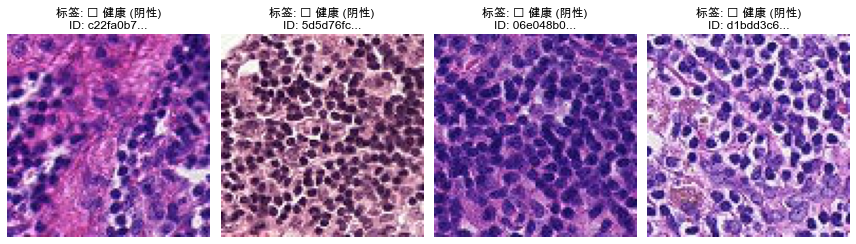

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

# 解决 Mac 电脑上 Matplotlib 中文显示为方块的问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False

print("正在加载图片进行可视化...")

# 随机选出 4 个样本的索引
random_indices = random.sample(range(len(labels_df)), 4)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(random_indices):
    img_id = labels_df.iloc[idx]['id']
    label = labels_df.iloc[idx]['label']
    
    # 拼接本地图片路径
    img_path = os.path.join(TRAIN_IMG_DIR, f"{img_id}.tif")
    
    # 读取图片
    img = Image.open(img_path)
    
    # 开始画图
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    
    # 根据标签判断中文含义 (1 代表有癌细胞组织，0 代表健康)
    status = "🔴 癌症 (阳性)" if label == 1 else "🟢 健康 (阴性)"
    plt.title(f"标签: {status}\nID: {img_id[:8]}...", fontsize=12)
    plt.axis('off') # 隐藏坐标轴

plt.tight_layout()
plt.show()


In [16]:
# 定义你想要保存的模型文件名
MODEL_SAVE_PATH = 'resnet50_cancer_model.pth'

# 提取模型的权重状态字典（State Dict）并保存
torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f"🎉 模型已成功保存！")
print(f"本地保存路径为: {os.path.abspath(MODEL_SAVE_PATH)}")
print("下次使用时，只需通过 torch.load() 即可一键加载该模型，无需重新训练。")


🎉 模型已成功保存！
本地保存路径为: /Users/mengchuwang/Desktop/上智/新規入学/研究室アルバイト/履歴書/KDDI/certifications/resnet50_cancer_model.pth
下次使用时，只需通过 torch.load() 即可一键加载该模型，无需重新训练。


In [ ]:
import os
import matplotlib.pyplot as plt

# 1. 定义保存路径（与你的模型在同一个目录下）
SAVE_DIR = "/Users/mengchuwang/Desktop/上智/新規入学/研究室アルバイト/履歴書/KDDI/certifications"
os.makedirs(SAVE_DIR, exist_ok=True)  # 如果文件夹不存在则自动创建

# 2. 假设你有一张正在显示的图片或图表
 plt.plot(train_losses, label='Training Loss') # 这里是你原本画图的代码
 plt.title('Cancer Model Training Loss')

# 3. 执行保存命令（指定文件名和分辨率）
image_path = os.path.join(SAVE_DIR, "training_result.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

print(f"✨ 图片已成功保存到本地！")
print(f"本地保存路径为：{image_path}")


IndentationError: unexpected indent (<ipython-input-22-1a2163373adf>, line 9)

In [21]:
import os
import matplotlib.pyplot as plt

# 1. 定义保存路径
SAVE_DIR = "/Users/mengchuwang/Desktop/上智/新規入学/研究室アルバイト/履歴書/KDDI/certifications"
os.makedirs(SAVE_DIR, exist_ok=True) 

# 2. 真正执行你的画图代码（去掉前面的 # 号）
# 注意：请确保你的环境里有 train_losses 这个变量
plt.plot(train_losses, label='Training Loss') 
plt.title('Cancer Model Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 3. 紧跟在画图代码后面执行保存命令
image_path = os.path.join(SAVE_DIR, "training_result.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

# 4. 最后再显示图片（显式关闭或展示，防止干扰）
plt.show()

print(f"✨ 图片已成功保存到本地！")
print(f"本地保存路径为：{image_path}")


NameError: name 'train_losses' is not defined